Part (c):

Plot the curve itself first:

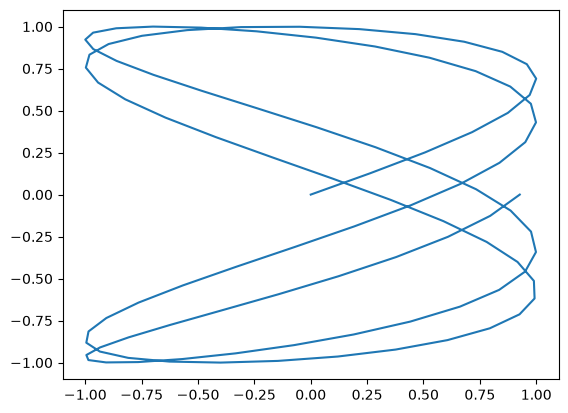

In [29]:
import matplotlib.pyplot as plt

a, b = 4, 2
delta = np.pi / 3
n = 100

t = np.linspace(0, 2 * np.pi, n)
x = np.sin(a * t * delta)
y = np.sin(b * t)

plt.plot(x, y)
plt.show()

Compute the discrete gradient:

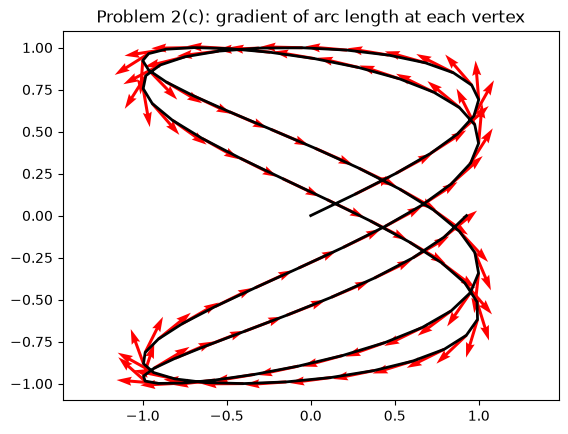

In [30]:
tan_x = np.zeros(n - 2)          # x-component of the gradient at interior vertices
tan_y = np.zeros(n - 2)          # y-component of the gradient at interior vertices
xy = np.vstack([x, y])       # shape (2, n), one column per vertex
diff = xy[:, 1:] - xy[:, :-1]  # shape (2, n-1), edge vectors x_{i+1} - x_i

diff_normalized = diff / np.linalg.norm(diff, axis=0)
tan_xy = diff_normalized [:, :-1] + diff_normalized[:, 1:]
tan_x, tan_y = tan_xy [0, :], tan_xy [1, :]

plt.figure()
plt.plot(x, y, linewidth=2, color="black")
plt.quiver(x[1:-1], y[1:-1], tan_x, tan_y, angles="xy", scale_units="xy", scale=8,
           linewidth=1, color="red")
plt.axis("equal")
plt.title("Problem 2(c): gradient of arc length at each vertex")
plt.show()


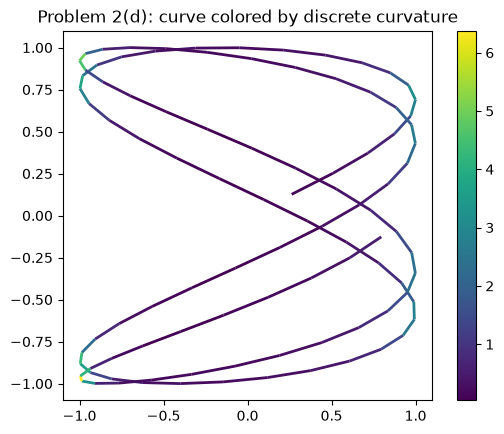

In [33]:
u = diff_normalized[:, :-1] # following the convention in the notes
v = -diff_normalized[:, 1:] # following the contention in the notes
variation = u + v

kappa_denom = np.linalg.norm(variation , axis=0)     # per-vertex (unsigned) discrete curvature
L = np.linalg.norm(diff, axis=0)
kappa = 2 * kappa_denom / (L[:-1] + L[:1])

from matplotlib.collections import LineCollection

X = x[1:-1]
Y = y[1:-1]
points = np.column_stack([X, Y]).reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
seg_vals = 0.5 * (kappa[:-1] + kappa[1:])
fig, ax = plt.subplots()
lc = LineCollection(segments, cmap="viridis", linewidth=2)
lc.set_array(seg_vals)
ax.add_collection(lc)
ax.autoscale()
ax.set_aspect("equal")
fig.colorbar(lc, ax=ax)
ax.set_title("Problem 2(d): curve colored by discrete curvature")
plt.show()

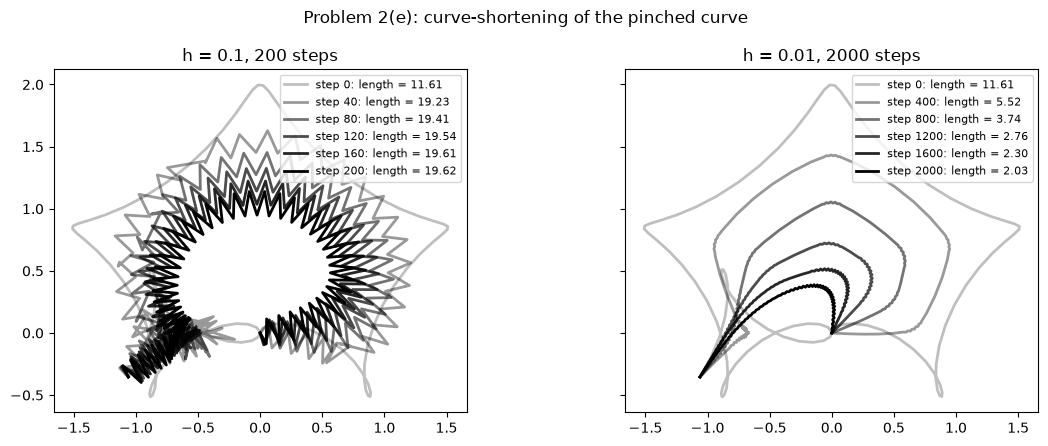

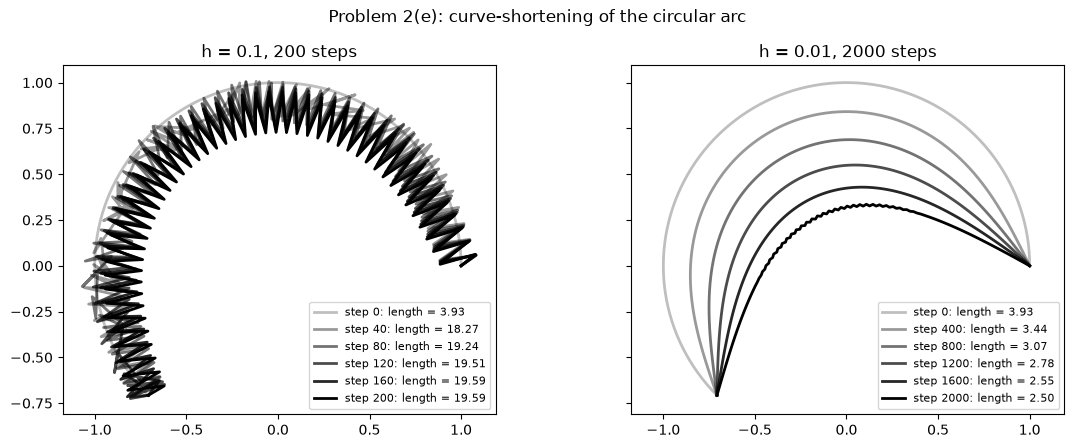

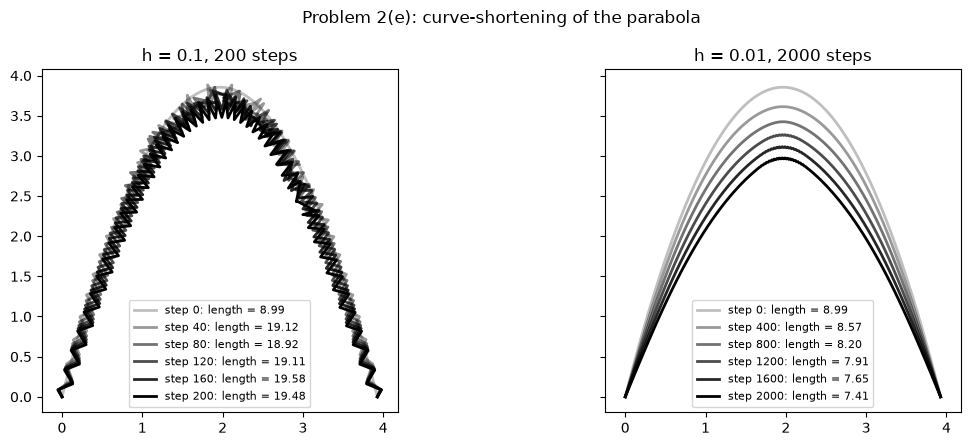

In [68]:
# ---------------------------------------------------------------- Problem 2(e)
t0 = 0.0
t1 = np.pi * 1.25
nSamples = 100
T = 20.0                      # total descent time, the same for every panel
nSnapshots = 5

# The three example curves from discreteCurve.m (each returns an (nSamples, 2) array)
curveFunctions = {
    "pinched curve":  lambda t: np.column_stack([np.cos(t) - np.cos(3 * t) ** 3, np.sin(t) - np.sin(3 * t) ** 3]),
    "circular arc":   lambda t: np.column_stack([np.cos(t), np.sin(t)]),
    "parabola":       lambda t: np.column_stack([t, (t - t0) * (t1 - t)]),
}


def curve_shortening(curve, h, nSteps):
    """Gradient descent on arc length with fixed endpoints. Returns the trajectory."""
    curve = curve.copy()
    trajectory = [curve.copy()]
    for i in range(nSteps):
        diff = curve[1:] - curve[:-1]                                 # (n-1, 2) edge vectors x_{i+1} - x_i
        diff_normalized = diff / np.linalg.norm(diff, axis=1, keepdims=True)
        u = diff_normalized[:-1]     # following the convention in the notes
        v = -diff_normalized[1:]     # following the convention in the notes
        variation = u + v            # (n-2, 2) gradient of s at the interior vertices
        curve[1:-1] -= h * variation
        trajectory.append(curve.copy())
    return trajectory


for name, curveFunction in curveFunctions.items():
    curve0 = curveFunction(np.linspace(t0, t1, nSamples))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
    for ax, h in zip(axes, [0.1, 0.01]):
        nSteps = int(round(T / h))
        trajectory = curve_shortening(curve0, h, nSteps)
        snapshot_steps = np.linspace(0, nSteps, nSnapshots + 1).astype(int)
        alphas = np.linspace(0.25, 1.0, len(snapshot_steps))    # black, fading in from start to end
        for k, alpha in zip(snapshot_steps, alphas):
            c = trajectory[k]
            length = np.linalg.norm(c[1:] - c[:-1], axis=1).sum()
            ax.plot(c[:, 0], c[:, 1], "k", linewidth=2, alpha=alpha,
                    label=f"step {k}: length = {length:.2f}")
        ax.set_title(f"h = {h}, {nSteps} steps")
        ax.set_aspect("equal")
        ax.legend(fontsize=8)
    fig.suptitle(f"Problem 2(e): curve-shortening of the {name}")
    plt.tight_layout()
    plt.show()
